# **Non-Stationary Spectral Decomposition Network (NS-SDN) For Econometric Forecasting**

Nikhil Sunder \
Student | ICSRI Research Fellow | Open-Source Developer \
B.S.B.A. Quantitative Economics, Finance & Minor in Math \
University of Miami Herbert Business School \
email: nss106@miami.edu \
phone: (305) 409-3108 \
links: [Github](https://github.com/nikhilxsunder) | [PyPI](https://pypi.org/user/nikhil.sunder/) | [Anaconda](https://anaconda.org/nikhil.sunder/) | [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) |
[ORCID](https://orcid.org/0009-0007-3323-1760) | [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22) | [Handshake](https://miami.joinhandshake.com/profiles/6pcqp4)

# NS-SDN: Testing & Validation

In [2]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import fedfred as fd

# ---------- device ----------
DEVICE = (
    torch.device("cpu")
)

torch.manual_seed(1337)
np.random.seed(1337)

print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
%run design.ipynb

In [4]:
fred=fd.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da")

In [5]:
# ---------- fetch + clean ----------
SERIES_ID = "CBETHUSD"
START_DATE = "2017-01-01"
H = 365  # holdout horizon

df = fred.get_series_observations(series_id=SERIES_ID, observation_start=START_DATE, units="log")

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

# daily grid; fill short gaps only
df = df.asfreq("D")
df["value"] = df["value"].ffill(limit=7)
df = df.dropna(subset=["value"])

dates_all = df.index.to_numpy()
y_all_np = df["value"].to_numpy(dtype=np.float32).reshape(-1, 1)  # log(price)

print("N:", len(df))
df.head()

N: 3351


,realtime_start,realtime_end,value
date,,,
2017-01-01,2026-03-06,2026-03-06,2.10169
2017-01-02,2026-03-06,2026-03-06,2.12585
2017-01-03,2026-03-06,2026-03-06,2.26072
2017-01-04,2026-03-06,2026-03-06,2.41323
2017-01-05,2026-03-06,2026-03-06,2.32532


In [6]:
# ---------- tensors ----------
y_all = torch.from_numpy(y_all_np).float()
t_all = make_time_grid(len(y_all), dt=1.0, start=0.0)

N = y_all.shape[0]
assert N > H + 1000, f"Not enough data. N={N}"

split = N - H

y_hist = y_all[:split]
y_fut  = y_all[split:]

t_hist = t_all[:split]
t_fut  = t_all[split:]

dates_hist = dates_all[:split]
dates_fut  = dates_all[split:]

print("Train:", y_hist.shape, "Holdout:", y_fut.shape)

Train: torch.Size([2986, 1]) Holdout: torch.Size([365, 1])


In [7]:
# ---------- scaling ----------
y_scaler = MapMinMax.fit(y_hist, target_min=-1.0, target_max=1.0)

y_hist_s = y_scaler.transform(y_hist)
y_fut_s  = y_scaler.transform(y_fut)

# full eval sequence for 1-step alignment
y_eval   = torch.cat([y_hist, y_fut], dim=0)
t_eval   = torch.cat([t_hist, t_fut], dim=0)
y_eval_s = y_scaler.transform(y_eval)

split_eval = y_hist.shape[0]

assert t_eval.shape[0] == y_eval_s.shape[0]

In [8]:
model = NSSDNStateSpace(
    y_dim=1,
    x_dim=0,
    h_dim=128,
    k=16,
    transition="gru",
    positive_omega=True,
    use_gating=True,
).to(DEVICE)

print("Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 58849


In [9]:
batch_tr = TimeSeriesBatch(t=t_hist, y=y_hist, x=None)

res_a = train_state_space_nssdn(
    model=model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=1e-3,
    steps=1200,
    teacher_forcing=True,
    use_nll=False,
    lam_A=2e-4,
    lam_omega=8e-4,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

model = res_a["model"]

In [ ]:
torch.save(model, "model_a_full.pth")

In [10]:
res_b = train_state_space_nssdn(
    model=model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=4e-4,
    steps=1800,
    teacher_forcing=True,
    use_nll=False,
    lam_A=3e-4,
    lam_omega=1.5e-3,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

model = res_b["model"]

In [16]:
torch.save(model, "model_b_full.pth")

In [11]:
with torch.no_grad():
    out = model.forward_sequence(
        t_eval.to(DEVICE),
        y_eval_s.to(DEVICE),
        teacher_forcing=True
    )

yhat_eval_s = out["yhat"].detach().cpu()

# 1-step ahead over holdout
yhat_1step_s = yhat_eval_s[split_eval-1:-1]
ytrue_hold_s = y_eval_s[split_eval:]

assert yhat_1step_s.shape == ytrue_hold_s.shape

In [12]:
# inverse scaling (still log-price)
hist_lp = y_scaler.inverse_transform(y_eval_s[:split_eval]).numpy().squeeze()
fut_lp  = y_scaler.inverse_transform(ytrue_hold_s).numpy().squeeze()
one_lp  = y_scaler.inverse_transform(yhat_1step_s).numpy().squeeze()

# convert log-price to price
hist_p = np.exp(hist_lp)
fut_p  = np.exp(fut_lp)
one_p  = np.exp(one_lp)

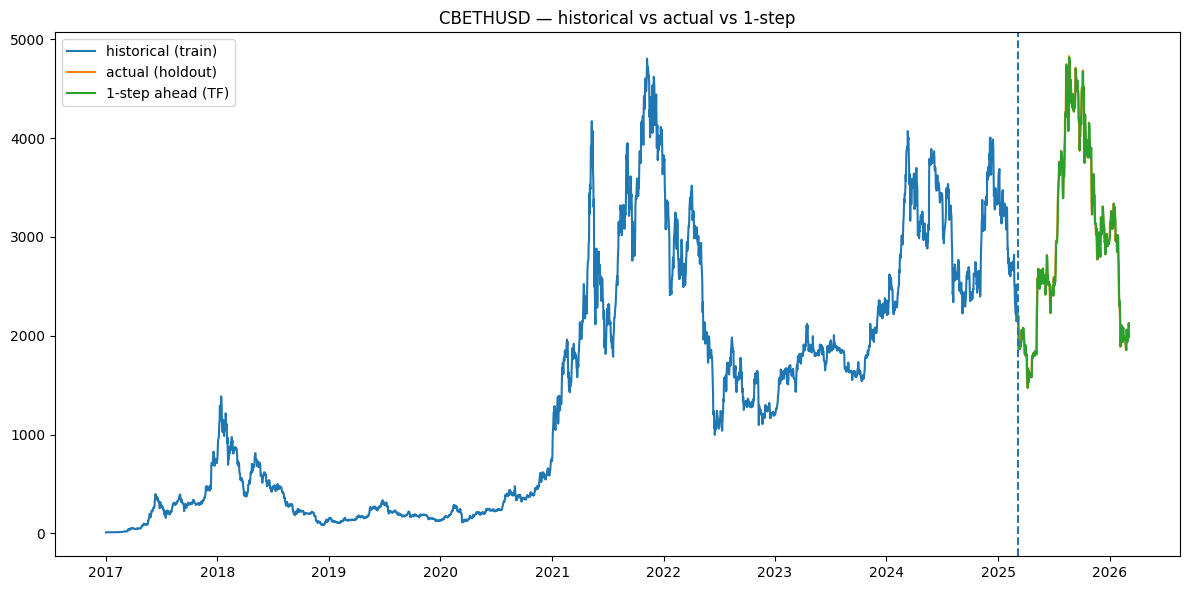

In [13]:
plt.figure(figsize=(12,6))
plt.plot(dates_hist, hist_p, label="historical (train)")
plt.plot(dates_fut,  fut_p,  label="actual (holdout)")
plt.plot(dates_fut,  one_p,  label="1-step ahead (TF)")
plt.axvline(dates_fut[0], linestyle="--")
plt.title("CBETHUSD — historical vs actual vs 1-step")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
rmse = float(np.sqrt(np.mean((one_p - fut_p) ** 2)))
mae  = float(np.mean(np.abs(one_p - fut_p)))
mape = float(np.mean(np.abs((one_p - fut_p) / fut_p)) * 100.0)

rmse, mae, mape

(115.13758850097656, 78.86678314208984, 2.66837215423584)

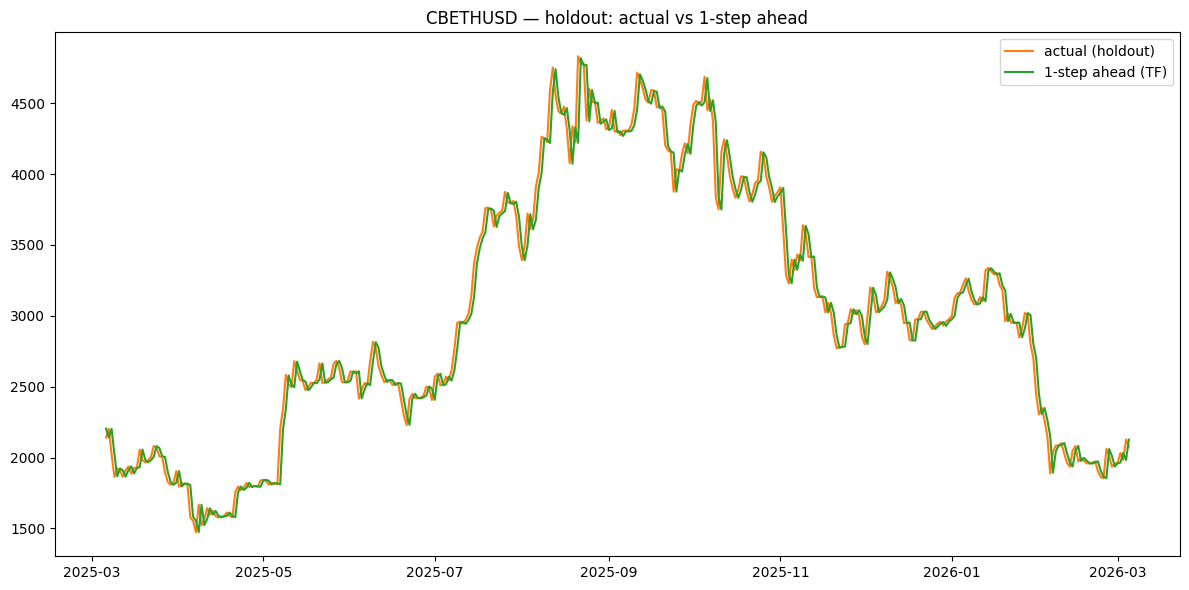

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(dates_fut, fut_p, label="actual (holdout)", color="tab:orange")
plt.plot(dates_fut, one_p, label="1-step ahead (TF)", color="tab:green")

plt.title("CBETHUSD — holdout: actual vs 1-step ahead")
plt.legend()
plt.tight_layout()
plt.show()